# LangChain과 비교
- LangChain
    - 간단한 LLM 애플리케이션이나 RAG(Retrieval-Augmented Generation) 시스템을 구축하는 데 주로 사용
    - 빠른 개발과 프로토타이핑이 필요한 프로젝트에 적합
- LangGraph
    - 복잡한 AI 시스템이나 다중 에이전트 시스템을 구축하는 데 적합
    - 여러 AI 모델이 상호작용하거나 복잡한 의사결정 과정이 필요한 프로젝트 적용

# LangGraph 기초
- 노드 작업 수행 -> 상태 업데이트 -> 엣지를 통한 전송 -> 반복

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

# 1단계: 데이터 저장소 만들기 (State)
# - State는 모든 노드가 공유하는 데이터
# - 여러 사람이 함께 사용하는 화이트보드
class CounterState(TypedDict):
    count: int

# 2단계: 작업 함수 만들기 (Node)
# - Node는 State를 받아서 새로운 State를 만듬
# - 실제 작업을 수행하는 Python 함수
def first_increment(state):
    print("첫 번째 증가")
    return {"count": state["count"] + 1}

def second_increment(state):
    print("두 번째 증가")
    return {"count": state["count"] + 10}


# 3단계: 그래프 만들기
# - Edge는 노드의 실행 순서를 정함
# - START → 작업 → END 순서로 실행
graph = StateGraph(CounterState)
graph.add_node("first", first_increment)
graph.add_node("second", second_increment)

graph.add_edge(START, "first")
graph.add_edge("first", "second") 
graph.add_edge("second", END)


# 4단계: 실행하기
# - 그래프를 실행 가능한 프로그램으로 만듬
# - 초깃값을 주고 그래프 실행
app = graph.compile()
result = app.invoke({"count": 0})
print(f"최종 결과: {result}")

첫 번째 증가
두 번째 증가
최종 결과: {'count': 11}


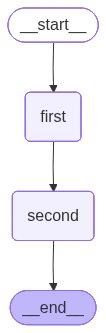

In [ ]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    pass

# State 관리
- Reducer
    - LangGraph에서 상태 업데이트 로직을 정의하는 핵심 메커니즘
    - 명시적 지정이 없으면 새 값이 기존 값을 완전히 대체
    - 메시지 전용 리듀서 add_messages
- MessagesState
    - messages 필드와 add_messages 리듀서가 미리 정의된 상태 클래스

In [ ]:
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph.message import add_messages
from typing import Annotated

class ChatState(TypedDict):
    messages: Annotated[list, add_messages]  # 메시지 전용 리듀서

def process_user_input(state: ChatState) -> ChatState:
    """
    add_messages 리듀서의 특징:
    1. 새 메시지는 리스트에 추가
    2. 동일한 ID를 가진 메시지는 업데이트
    3. 자동으로 메시지 객체로 역직렬화
    """
    return {
        "messages": [HumanMessage(content="사용자 입력", id="msg_001")]
    }

# MessagesState 사용 (더 간편한 방법)
from langgraph.graph import MessagesState

class MyState(MessagesState):
    pass  # MessagesState를 상속받으면 messages 필드와 add_messages 리듀서가 자동 포함


In [ ]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_core.messages import HumanMessage, AIMessage

class ChatState(MessagesState):
    user_name: str

def greet_user(state: ChatState) -> dict:
    """사용자 인사 처리"""
    user_msg = state["messages"][-1]
    response = AIMessage(
        content=f"안녕하세요, {state['user_name']}님! 무엇을 도와드릴까요?"
    )
    return {"messages": [response]}

def process_question(state: ChatState) -> dict:
    """질문 처리"""
    user_msg = state["messages"][-1]
    response = AIMessage(
        content=f"'{user_msg.content}'에 대한 답변입니다."
    )
    return {"messages": [response]}

# 그래프 구성
graph = StateGraph(ChatState)
graph.add_node("greet", greet_user)
graph.add_node("answer", process_question)

graph.add_edge(START, "greet")
graph.add_edge("greet", "answer")
graph.add_edge("answer", END)

app = graph.compile()

# 실행
result = app.invoke({
    "messages": [HumanMessage(content="안녕하세요")],
    "user_name": "홍길동"
})

print(f"메시지 수: {len(result['messages'])}")
for msg in result["messages"]:
    role = "User" if isinstance(msg, HumanMessage) else "AI"
    print(f"{role}: {msg.content}")


In [ ]:
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    pass

# Node 추가
- 업데이트할 상태 딕셔너리 반환
- 모듈성과 재사용성 강조

In [ ]:
from typing import TypedDict, Dict, Any
from langgraph.graph import StateGraph

# 상태 정의
class State(TypedDict):
    counter: int
    messages: list
    status: str

# 기본 노드 함수
def increment(state: State) -> Dict[str, Any]:
    """
    가장 간단한 형태의 노드

    Args:
        state: 현재 그래프 상태

    Returns:
        Dict: 업데이트할 상태
    """
    # 현재 카운터 값 가져오기
    current_counter = state["counter"]

    # 비즈니스 로직 수행
    new_counter = current_counter + 1

    # 상태 업데이트 반환
    return {
        "counter": new_counter,
        "messages": [f"카운터가 {new_counter}로 증가했습니다."],
        "status": "incremented"
    }

# 그래프 생성 및 노드 추가
graph = StateGraph(State)
graph.add_node("increment", increment)  # 노드 이름과 함수 매핑


In [ ]:
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    pass

- 노드 패턴
    - 조건부 노드
    - 검증 노드

In [ ]:
def conditional_node(state: State) -> Dict[str, Any]:
    """
    조건부 노드 - 상태에 따라 다른 처리 수행
    """
    mode = state.get("mode", "default")

    if mode == "fast":
        # 빠른 처리
        result = quick_process(state)
        execution_time = "fast"
    elif mode == "thorough":
        # 정밀 처리
        result = thorough_process(state)
        execution_time = "slow"
    else:
        # 기본 처리
        result = default_process(state)
        execution_time = "normal"

    return {
        "result": result,
        "execution_time": execution_time,
        "mode_used": mode
    }

def quick_process(state):
    return {"status": "quick", "data": state.get("input", "")[:10]}

def thorough_process(state):
    return {"status": "thorough", "data": analyze_deeply(state.get("input", ""))}

def default_process(state):
    return {"status": "default", "data": state.get("input", "")}

def analyze_deeply(data):
    # 심층 분석 로직
    return f"Deeply analyzed: {data}"


In [ ]:
from typing import Optional

class ValidationState(TypedDict):
    input_data: Any
    validation_errors: list[str]
    is_valid: bool

def validation_node(state: ValidationState) -> Dict[str, Any]:
    """
    검증 노드 - 데이터 유효성 검사
    """
    input_data = state["input_data"]
    errors = []

    # 다양한 검증 수행
    if not input_data:
        errors.append("입력 데이터가 비어있습니다.")

    if isinstance(input_data, str):
        if len(input_data) < 3:
            errors.append("문자열이 너무 짧습니다 (최소 3자).")
        if len(input_data) > 1000:
            errors.append("문자열이 너무 깁니다 (최대 1000자).")
        if not input_data.isascii():
            errors.append("ASCII 문자만 허용됩니다.")

    elif isinstance(input_data, (int, float)):
        if input_data < 0:
            errors.append("음수는 허용되지 않습니다.")
        if input_data > 1000000:
            errors.append("값이 너무 큽니다 (최대 1,000,000).")

    elif isinstance(input_data, list):
        if len(input_data) == 0:
            errors.append("리스트가 비어있습니다.")
        if len(input_data) > 100:
            errors.append("리스트 항목이 너무 많습니다 (최대 100개).")

    # 검증 결과 반환
    return {
        "validation_errors": errors,
        "is_valid": len(errors) == 0
    }


- 노드 고급 패턴
    - 클래스 기반 노드
        - 노드가 내부 상태를 유지
        - 복잡한 로직을 캡슐화
        - 여러 메서드를 통해 기능을 분리
    - 팩토리 패턴 노드
        - 런타임에 다양한 타입의 노드를 동적으로 생성
        - 코드 중복을 줄이고 노드 생성 로직을 중앙화

In [ ]:
class DataProcessorNode:
    """
    클래스 기반 노드
    상태를 가지고 복잡한 로직을 구현할 때 유용
    """

    def __init__(self, processor_type: str = "standard"):
        self.processor_type = processor_type
        self.processing_count = 0
        self.cache = {}

    def __call__(self, state: State) -> Dict[str, Any]:
        """
        노드 실행 메서드
        클래스 인스턴스를 호출 가능하게 만듦
        """
        input_data = state["input"]

        # 캐시 확인
        cache_key = f"{self.processor_type}:{input_data}"
        if cache_key in self.cache:
            print(f"Cache hit for {cache_key}")
            return {"output": self.cache[cache_key], "from_cache": True}

        # 처리 수행
        if self.processor_type == "standard":
            result = self._standard_process(input_data)
        elif self.processor_type == "advanced":
            result = self._advanced_process(input_data)
        else:
            result = self._default_process(input_data)

        # 통계 업데이트
        self.processing_count += 1

        # 캐시 저장
        self.cache[cache_key] = result

        return {
            "output": result,
            "processor_type": self.processor_type,
            "total_processed": self.processing_count,
            "from_cache": False
        }

    def _standard_process(self, data):
        return f"Standard processed: {data}"

    def _advanced_process(self, data):
        return f"Advanced processed: {data}"

    def _default_process(self, data):
        return f"Default processed: {data}"

# 사용 예시
processor = DataProcessorNode(processor_type="advanced")
graph.add_node("processor", processor)


In [ ]:
def create_processing_node(node_type: str, **kwargs):
    """
    노드 팩토리 함수
    다양한 타입의 노드를 동적으로 생성
    """

    if node_type == "transformer":
        def transformer_node(state: State) -> Dict[str, Any]:
            transform_func = kwargs.get("transform_func", lambda x: x)
            input_field = kwargs.get("input_field", "input")
            output_field = kwargs.get("output_field", "output")

            transformed = transform_func(state[input_field])
            return {output_field: transformed}

        return transformer_node

    elif node_type == "filter":
        def filter_node(state: State) -> Dict[str, Any]:
            filter_func = kwargs.get("filter_func", lambda x: True)
            items_field = kwargs.get("items_field", "items")

            filtered = [item for item in state[items_field] if filter_func(item)]
            return {items_field: filtered}

        return filter_node

    elif node_type == "aggregator":
        def aggregator_node(state: State) -> Dict[str, Any]:
            agg_func = kwargs.get("agg_func", sum)
            values_field = kwargs.get("values_field", "values")
            result_field = kwargs.get("result_field", "result")

            aggregated = agg_func(state[values_field])
            return {result_field: aggregated}

        return aggregator_node

    else:
        raise ValueError(f"Unknown node type: {node_type}")

# 팩토리로 노드 생성
uppercase_node = create_processing_node(
    "transformer",
    transform_func=lambda x: x.upper(),
    input_field="text",
    output_field="uppercase_text"
)

positive_filter = create_processing_node(
    "filter",
    filter_func=lambda x: x > 0,
    items_field="numbers"
)

sum_aggregator = create_processing_node(
    "aggregator",
    agg_func=sum,
    values_field="scores",
    result_field="total_score"
)

# 그래프에 추가
graph.add_node("uppercase", uppercase_node)
graph.add_node("filter_positive", positive_filter)
graph.add_node("calculate_sum", sum_aggregator)


# Edge 설정
- 일반 엣지: 항상 고정된 경로로 이동
- 조건부 엣지: 조건에 따라 다른 노드로 라우팅

In [ ]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(State)
graph.add_node("process", process_node)
graph.add_node("output", output_node)

# 엣지 정의
graph.add_edge(START, "process")      # 시작 -> process
graph.add_edge("process", "output")   # process -> output
graph.add_edge("output", END)         # output -> 종료


In [ ]:
from typing import Literal

class ConditionalState(TypedDict):
    user_input: str
    sentiment: str
    response: str

def analyze_sentiment(state: ConditionalState) -> dict:
    """감정 분석 노드"""
    text = state["user_input"].lower()

    # 간단한 감정 분석 (실제로는 ML 모델 사용)
    if any(word in text for word in ["happy", "great", "awesome", "love"]):
        sentiment = "positive"
    elif any(word in text for word in ["sad", "bad", "hate", "terrible"]):
        sentiment = "negative"
    else:
        sentiment = "neutral"

    return {"sentiment": sentiment}

def positive_response(state: ConditionalState) -> dict:
    """긍정적 응답 생성"""
    return {"response": f"😊 That's wonderful! I'm glad you feel that way about: {state['user_input']}"}

def negative_response(state: ConditionalState) -> dict:
    """부정적 응답 생성"""
    return {"response": f"😔 I understand that's difficult. Let me help with: {state['user_input']}"}

def neutral_response(state: ConditionalState) -> dict:
    """중립적 응답 생성"""
    return {"response": f"📝 I see. Let me process your request: {state['user_input']}"}

# 라우팅 함수
def sentiment_router(state: ConditionalState) -> Literal["positive", "negative", "neutral"]:
    """감정에 따라 라우팅"""
    return state["sentiment"]

# 조건부 엣지를 사용한 그래프
sentiment_graph = StateGraph(ConditionalState)
sentiment_graph.add_node("analyze", analyze_sentiment)
sentiment_graph.add_node("positive", positive_response)
sentiment_graph.add_node("negative", negative_response)
sentiment_graph.add_node("neutral", neutral_response)

# 조건부 엣지 설정
sentiment_graph.add_edge(START, "analyze")
sentiment_graph.add_conditional_edges(
    "analyze",
    sentiment_router,
    {
        "positive": "positive",
        "negative": "negative",
        "neutral": "neutral"
    }
)
sentiment_graph.add_edge("positive", END)
sentiment_graph.add_edge("negative", END)
sentiment_graph.add_edge("neutral", END)


In [ ]:
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    pass

# Compile
- 실행 방법
    - invoke
        - 동기 실행, 최종 결과 반환
        - 배치 처리, 테스트 목적
    - stream
        - 동기 스트리밍, 중간 결과 반환
        - 실시간 UI 목적
        - 스트림 모드 종류
            - values: 각 단계 후 전체 상태
            - messages: LLM 토큰 단위 스트리밍
- 핵심 원칙: 관심사 분리

In [ ]:
graph = StateGraph(MyState)  # 그래프 정의
app = graph.compile()  # 그래프 컴파일
result = app.invoke({"counter": 0})  # 그래프 실행
print(result)  # 결과 출력

In [ ]:
from langgraph.graph import StateGraph, START, END
from datetime import datetime

class WorkflowState(TypedDict):
    input_data: str
    processing_stage: str
    results: Annotated[list, operator.add]
    error: Optional[str]
    metadata: dict

# 노드 함수들 정의
def validate_input(state: WorkflowState) -> dict:
    """입력 검증 노드"""
    input_data = state["input_data"]

    if not input_data:
        return {
            "error": "입력 데이터가 비어있습니다",
            "processing_stage": "validation_failed"
        }

    if len(input_data) > 1000:
        return {
            "error": "입력 데이터가 너무 깁니다",
            "processing_stage": "validation_failed"
        }

    return {
        "processing_stage": "validated",
        "results": ["입력 검증 완료"]
    }

def process_data(state: WorkflowState) -> dict:
    """데이터 처리 노드"""
    # 실제 처리 로직
    processed = state["input_data"].upper()

    return {
        "processing_stage": "processed",
        "results": [f"처리 결과: {processed}"],
        "metadata": {
            **state.get("metadata", {}),
            "processed_at": datetime.now().isoformat()
        }
    }

def generate_output(state: WorkflowState) -> dict:
    """출력 생성 노드"""
    final_output = "\n".join(state["results"])

    return {
        "processing_stage": "completed",
        "results": [f"최종 출력: {final_output}"],
        "metadata": {
            **state["metadata"],
            "completed_at": datetime.now().isoformat()
        }
    }

def handle_error(state: WorkflowState) -> dict:
    """에러 처리 노드"""
    return {
        "processing_stage": "error_handled",
        "results": [f"에러 처리: {state['error']}"]
    }

# 라우팅 함수
def route_after_validation(state: WorkflowState) -> str:
    """검증 후 라우팅"""
    if state.get("error"):
        return "error"
    return "process"

# 그래프 구성
workflow = StateGraph(WorkflowState)

# 노드 추가
workflow.add_node("validate", validate_input)
workflow.add_node("process", process_data)
workflow.add_node("output", generate_output)
workflow.add_node("error_handler", handle_error)

# 엣지 추가
workflow.add_edge(START, "validate")
workflow.add_conditional_edges(
    "validate",
    route_after_validation,
    {
        "process": "process",
        "error": "error_handler"
    }
)
workflow.add_edge("process", "output")
workflow.add_edge("output", END)
workflow.add_edge("error_handler", END)

# 그래프 컴파일
app = workflow.compile()


In [ ]:
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    pass

# Memory
- 그래프의 상태를 저장하고 복원
- 대화의 맥락을 유지, 오류 발생 시 안전하게 복구, 사용자별로 개인화된 경험 제공
- 체크포인터는 게임의 세이브 포인트
    - InMemorySaver: 개발/테스트용 (프로세스 종료 시 데이터 소멸)
    - SqliteSaver: 로컬 파일 기반 영구 저장
    - PostgresSaver: 프로덕션 환경용 (다중 인스턴스 지원)
- thread_id: 대화 세션을 구분하는 고유 식별자

In [ ]:
from typing import TypedDict
from langchain.chat_models import init_chat_model
from langchain.messages import AIMessage
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

# 1단계: 모델 초기화
# init_chat_model()을 사용하면 다양한 LLM 제공사를 통일된 방식으로 사용 가능
model = init_chat_model("anthropic:claude-sonnet-4-5-20250929")

# 2단계: 챗봇 노드 정의
def chatbot_node(state: MessagesState) -> dict:
    """
    사용자 메시지를 받아 AI 응답을 생성하는 노드

    Args:
        state: MessagesState - 대화 히스토리가 포함된 상태

    Returns:
        dict - AI 응답 메시지를 포함한 딕셔너리
    """
    # 모델을 호출하여 응답 생성
    response = model.invoke(state["messages"])

    # 응답을 messages 키에 담아 반환
    return {"messages": [response]}

# 3단계: InMemorySaver 체크포인터 생성
# 별도 설정 없이 인스턴스만 생성하면 사용 가능
checkpointer = InMemorySaver()

# 4단계: StateGraph 구성
# MessagesState를 사용하면 messages 필드가 자동으로 관리됨
builder = StateGraph(MessagesState)

# 챗봇 노드 추가
builder.add_node("chatbot", chatbot_node)

# 엣지 연결: START -> chatbot -> END
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

# 5단계: 그래프 컴파일 (체크포인터 설정)
# checkpointer를 지정하면 대화 상태가 자동으로 저장됨
graph = builder.compile(checkpointer=checkpointer)

# 6단계: 그래프 실행
# thread_id로 대화 세션 구분
config = {"configurable": {"thread_id": "conversation_1"}}

# 첫 번째 메시지 전송
result1 = graph.invoke(
    {"messages": [{"role": "user", "content": "안녕하세요! 제 이름은 철수입니다."}]},
    config
)
print("AI 응답 1:", result1["messages"][-1].content)

# 두 번째 메시지 전송 (이전 대화 기억)
result2 = graph.invoke(
    {"messages": [{"role": "user", "content": "제 이름이 뭐였죠?"}]},
    config
)
print("AI 응답 2:", result2["messages"][-1].content)


In [ ]:
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    pass

체크포인터에 저장된 상태를 확인 방법

In [ ]:
from pprint import pprint

# 특정 thread의 현재 상태 가져오기
state = graph.get_state(config)

# 저장된 값 출력
print("=== 저장된 상태 값 ===")
pprint(state.values)

# 설정 정보 출력
print("\n=== 설정 정보 ===")
pprint(state.config)

# 메시지 개수 확인
print(f"\n총 메시지 수: {len(state.values['messages'])}")
